# 05 — Auto-discovery: monitor pairs nobody hand-picked

Notebook 02 monitors relationships we chose because we have an economic
story for them. But incoherence can appear in relationships you never
thought to list. This notebook scales the same detection to **every
strongly-correlated pair in the whole universe**, automatically.

### The idea

1. Take every ticker in `UNIVERSE` (≈30 of them in `pairs_config.py`).
2. Compute the correlation of daily moves for **every possible pair**
   (30 tickers → 435 combinations).
3. Keep pairs with |correlation| ≥ 0.40 — a relationship strong enough
   that breaking it MEANS something. Weak pairs would just alert on noise.
4. Run the exact same breakdown/reversion state machine from notebook 02
   on all of them. Baseline sign = each pair's own 1-year correlation
   ("whatever you've been doing for a year is your normal").

The logic lives in `engine.py` — the same file `run_daily.py` uses, so
what you study here is exactly what runs automatically every day.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import engine
from pairs_config import CORE_PAIRS, UNIVERSE

prices = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
print(f"{len(prices.columns)} tickers, {len(prices)} days "
      f"-> {len(prices.columns) * (len(prices.columns) - 1) // 2} possible pairs")

30 tickers, 784 days -> 435 possible pairs


### The correlation matrix of the whole universe

One picture of "how everything relates to everything". Deep red/blue =
a strong relationship worth monitoring; near-white = noise we skip.

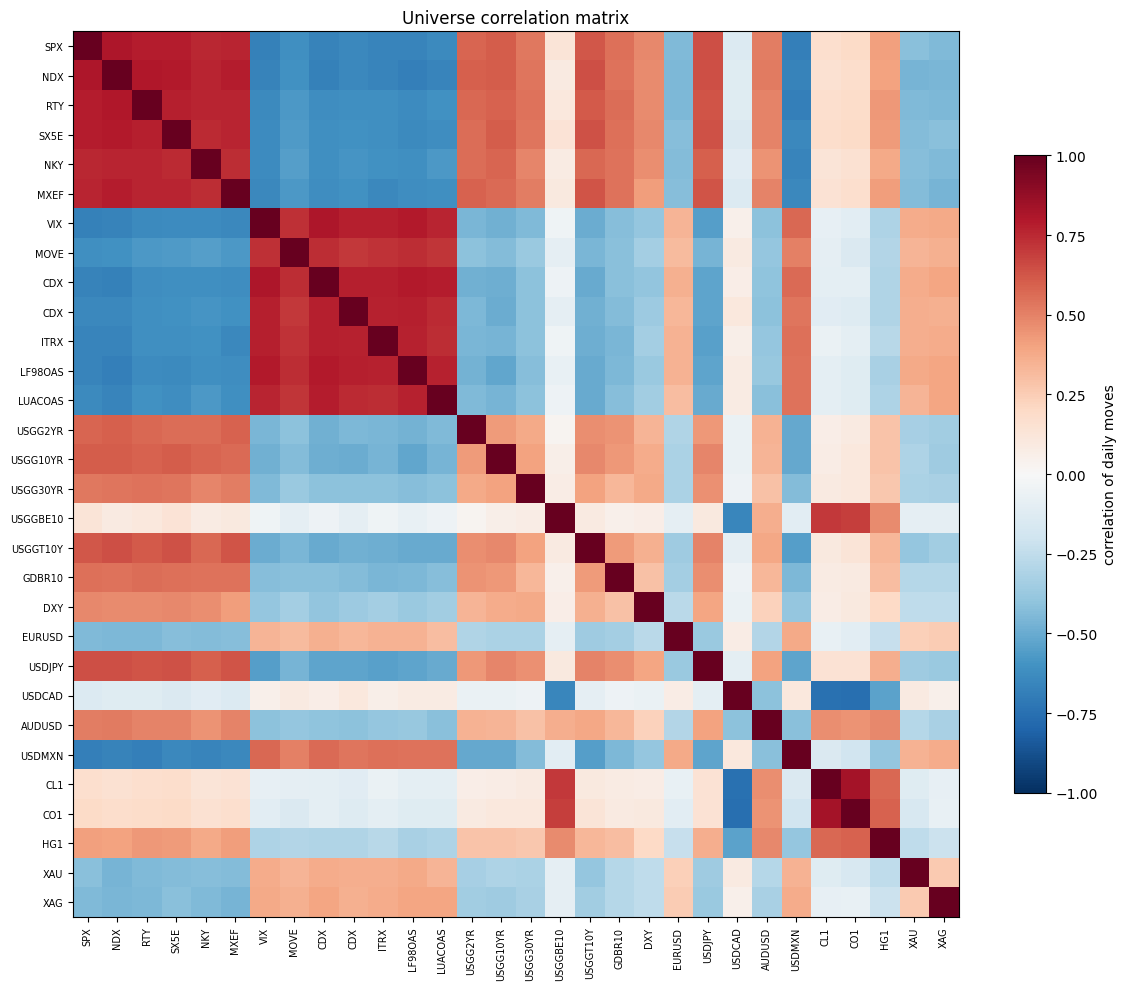

In [2]:
moves = pd.DataFrame({t: engine.to_moves(prices[t], tr)
                      for t, tr in UNIVERSE.items() if t in prices.columns})
corr = moves.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
short = [t.split()[0] for t in corr.columns]
ax.set_xticks(range(len(short))); ax.set_xticklabels(short, rotation=90, fontsize=7)
ax.set_yticks(range(len(short))); ax.set_yticklabels(short, fontsize=7)
fig.colorbar(im, shrink=0.7, label="correlation of daily moves")
ax.set_title("Universe correlation matrix")
plt.tight_layout()
plt.show()

### Discover and run

`build_auto_pairs` keeps combinations with |corr| ≥ 0.40 that are not
already in CORE_PAIRS, then `run_detection` runs the notebook-02 state
machine on each and writes events/status to the same `incoherence.db`.

In [3]:
auto_pairs = engine.build_auto_pairs(prices, CORE_PAIRS)
print(f"Auto-discovered {len(auto_pairs)} pairs. First few:")
for p in auto_pairs[:8]:
    print("  ", p["name"], "-", p["description"])

Auto-discovered 228 pairs. First few:
   AUTO: SPX vs NDX - Auto-discovered (full-sample corr +0.81). Baseline = own 1y correlation.
   AUTO: SPX vs RTY - Auto-discovered (full-sample corr +0.78). Baseline = own 1y correlation.
   AUTO: SPX vs SX5E - Auto-discovered (full-sample corr +0.78). Baseline = own 1y correlation.
   AUTO: SPX vs NKY - Auto-discovered (full-sample corr +0.75). Baseline = own 1y correlation.
   AUTO: SPX vs MXEF - Auto-discovered (full-sample corr +0.77). Baseline = own 1y correlation.
   AUTO: SPX vs MOVE - Auto-discovered (full-sample corr -0.61). Baseline = own 1y correlation.
   AUTO: SPX vs ITRX - Auto-discovered (full-sample corr -0.66). Baseline = own 1y correlation.
   AUTO: SPX vs LUACOAS - Auto-discovered (full-sample corr -0.64). Baseline = own 1y correlation.


In [4]:
summary = engine.run_detection(prices, auto_pairs, verbose=False)

broken = summary[summary["state"] == "BROKEN"]
busiest = summary.sort_values("events", ascending=False).head(10)

print(f"\nCurrently BROKEN: {len(broken)}")
if len(broken):
    print(broken.to_string(index=False))
print("\nMost event-prone auto pairs:")
print(busiest.to_string(index=False))


Currently BROKEN: 2
                   pair  state  events  corr_short  corr_long
    AUTO: CDX vs GDBR10 BROKEN       1       -0.61      -0.17
AUTO: LF98OAS vs GDBR10 BROKEN       1       -0.64      -0.17

Most event-prone auto pairs:
                 pair  state  events  corr_short  corr_long
AUTO: CDX vs USGG30YR NORMAL       4       -0.67      -0.27
  AUTO: SPX vs EURUSD NORMAL       2        0.06      -0.42
    AUTO: SPX vs ITRX NORMAL       2       -0.79      -0.42
 AUTO: SPX vs LUACOAS NORMAL       2       -0.86      -0.39
    AUTO: NDX vs MOVE NORMAL       2       -0.78      -0.37
 AUTO: NDX vs LUACOAS NORMAL       2       -0.92      -0.41
 AUTO: NDX vs LF98OAS NORMAL       2       -0.78      -0.41
    AUTO: NDX vs ITRX NORMAL       2       -0.83      -0.44
     AUTO: SPX vs XAG NORMAL       2       -0.40      -0.44
     AUTO: NDX vs CDX NORMAL       2       -0.85      -0.43


### Reading the results

- Auto pairs are labelled `AUTO:` in the database so the dashboard can
  separate them from your hand-picked, story-backed pairs.
- Expect auto pairs to be noisier — two tickers can be correlated only
  because they share a driver (NDX and RTY both follow SPX). A break can
  mean the *driver* relationship broke. Check the core pairs first.
- If 435 combinations gives you too many alerts, raise `MIN_AUTO_CORR`
  in `pairs_config.py` to 0.5–0.6: fewer, higher-conviction pairs.